In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("/home/armanshaikh/Downloads/Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [14]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

In [16]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [17]:
y_pred = model.predict(X_test)

In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [19]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

Accuracy: 1.0
Error Rate: 0.0


In [20]:
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)

Precision: 1.0
Recall: 1.0


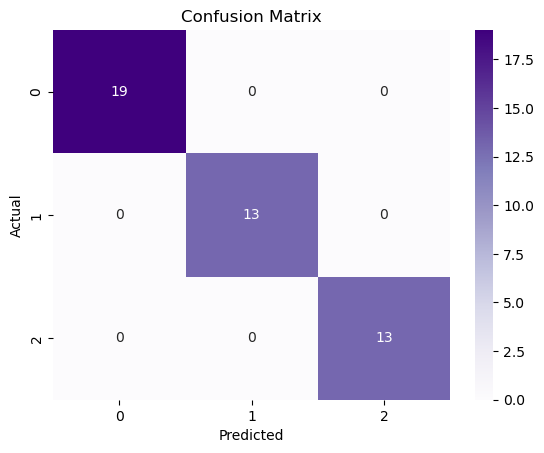

In [21]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
for i in range(len(cm)):
    TP = cm[i, i]
    FP = sum(cm[:, i]) - TP
    FN = sum(cm[i, :]) - TP
    TN = sum(cm) - (TP + FP + FN)
    print(f"\nClass {i}:")
    print("TP:", TP, "FP:", FP, "FN:", FN, "TN:", TN)


Class 0:
TP: 19 FP: 0 FN: 0 TN: [ 0 -6 -6]

Class 1:
TP: 13 FP: 0 FN: 0 TN: [6 0 0]

Class 2:
TP: 13 FP: 0 FN: 0 TN: [6 0 0]
